# JAX for numerical computing: waves, state, and conservation

This tutorial uses JAX to solve the one-dimensional wave equation. The equation is simple enough to analyse exactly, but rich enough to expose issues that a diffusion problem hides: a second-order state, a CFL stability limit, conserved energy, and numerical dispersion.

The aim is not merely to obtain a moving curve. We will ask whether the implementation converges at the expected rate, respects a discrete invariant, and produces a meaningful derivative.

> Compilation can make a simulation fast; it cannot make an unstable or poorly resolved discretization trustworthy.

## How to use this tutorial

**Audience.** Scientific Python users familiar with NumPy arrays and basic calculus. No machine-learning experience is required.

**Prerequisites.** Required: array indexing, functions, and the meaning of first and second derivatives. Helpful but optional: finite differences and Fourier modes.

**Time.** Allow 50–65 minutes for the guided material and 20–35 minutes for the two exercises. Run all cells in order from a fresh kernel. Complete solutions follow each exercise.

**Environment.** Use the `environment.yml` in this directory. Package installation is kept outside the notebook so that setup remains reproducible. The same code runs on CPU and supported accelerators.

## Learning objectives

By the end, you should be able to:

1. represent a second-order time integrator using a tuple PyTree as explicit loop state;
2. choose between `jax.lax.fori_loop` and `jax.lax.scan` according to the required output;
3. use `jax.vmap` over corresponding axes of multiple arguments;
4. apply and diagnose the CFL stability restriction of an explicit wave solver;
5. validate a solution using an exact mode, grid refinement, and a discrete energy;
6. explain numerical dispersion rather than treating every stable wave as accurate; and
7. differentiate a scalar wave diagnostic while keeping discrete choices fixed.

## 1. Setup and numerical precision

We enable 64-bit arithmetic because the conservation experiment measures small energy changes. This is a deliberate accuracy choice, not a performance recommendation. Many GPUs have much lower 64-bit than 32-bit throughput. Configure precision before creating JAX arrays.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(f"JAX version: {jax.__version__}")
print(f"Default backend: {jax.default_backend()}")
for device in jax.devices():
    print(f"  {device}")

JAX version: 0.10.2


Default backend: gpu
  cuda:0


A CPU result is valid. If you expected an accelerator and do not see one, correct the environment before interpreting performance. This notebook tests numerical behaviour, not CPU-versus-GPU speed.

## 2. Model problem

We solve the periodic wave equation

$$
\frac{\partial^2 u}{\partial t^2}=c^2\frac{\partial^2u}{\partial x^2},
\qquad 0\le x<L,
$$

where $c>0$ is the wave speed. A complete initial-value problem needs both displacement and velocity:

$$u(x,0)=u_0(x), \qquad \frac{\partial u}{\partial t}(x,0)=v_0(x).$$

For $u_0(x)=\sin(kx)$, $v_0(x)=0$, and $k=2\pi m/L$, the exact standing wave is

$$u(x,t)=\cos(ckt)\sin(kx).$$

The exact solution gives us an independent reference for the implementation.

## 3. Leapfrog finite differences

Use centred differences in space and time:

$$
u_i^{n+1}=2u_i^n-u_i^{n-1}
+\left(\frac{c\Delta t}{\Delta x}\right)^2
(u_{i-1}^n-2u_i^n+u_{i+1}^n).
$$

The state is therefore a pair $(u^{n-1},u^n)$. A step consumes that pair and returns $(u^n,u^{n+1})$. In JAX, the Python tuple `(previous, current)` is a **PyTree**: the tuple is its fixed container structure and the two arrays are its leaves. Using a PyTree as loop state is a programming pattern for advancing related arrays together; it does not pack them into one array or introduce a new storage layout. The structure, leaf shapes, and leaf dtypes must remain compatible from one loop iteration to the next.

The one-dimensional stability condition is

$$\lambda=\frac{c\Delta t}{\Delta x}\le 1.$$

Stability is necessary, not sufficient for accuracy. A poorly resolved wave may remain bounded while travelling at the wrong numerical speed.

In [2]:
def laplacian_periodic(u, dx):
    """Second-order centred Laplacian on a periodic one-dimensional grid."""
    return (jnp.roll(u, 1) - 2.0 * u + jnp.roll(u, -1)) / dx**2


def standing_wave_exact(x, t, speed, length=1.0, mode=1):
    """Exact standing wave with unit initial amplitude and zero velocity."""
    wave_number = 2.0 * jnp.pi * mode / length
    return jnp.cos(speed * wave_number * t) * jnp.sin(wave_number * x)

A two-step method needs $u^1$ before it can use the recurrence. A Taylor expansion gives a second-order consistent start:

$$u^1=u^0+\Delta t\,v^0+\tfrac{1}{2}c^2\Delta t^2D_{xx}u^0.$$

Using $u^1=u^0$ when the initial velocity is zero looks plausible but reduces the temporal accuracy. Initialization is part of the numerical method, not boilerplate.

In [3]:
def initialize_wave(u0, v0, speed, dt, dx):
    """Construct the first displacement with a second-order Taylor step."""
    return u0 + dt * v0 + 0.5 * speed**2 * dt**2 * laplacian_periodic(u0, dx)


def wave_step(state, speed, dt, dx):
    """Map (previous, current) displacement to (current, next)."""
    previous, current = state
    following = (
        2.0 * current
        - previous
        + speed**2 * dt**2 * laplacian_periodic(current, dx)
    )
    return current, following

### Final state or complete history?

Both loop forms carry the same two-array PyTree. Use `fori_loop` when only the final state is needed: intermediate arrays need not be returned. Use `scan` when every step is required for plotting or diagnostics. `scan` returns both the final carry and the stacked per-step outputs; `wave_history` ignores the final carry because the selected displacement history is the required result. Storing a history of $N_t$ states with $N_x$ values costs $O(N_tN_x)$ memory, so it is not a harmless change for a large simulation.

In [4]:
def solve_wave(u0, v0, speed, dt, dx, n_steps):
    """Return only the displacement after n_steps."""
    u1 = initialize_wave(u0, v0, speed, dt, dx)

    def body(_, state):
        return wave_step(state, speed, dt, dx)

    _, final = jax.lax.fori_loop(1, n_steps, body, (u0, u1))
    return final


def wave_history(u0, v0, speed, dt, dx, n_steps):
    """Return displacements at steps 0 through n_steps."""
    u1 = initialize_wave(u0, v0, speed, dt, dx)

    def body(state, _):
        new_state = wave_step(state, speed, dt, dx)
        return new_state, new_state[1]

    _, later_states = jax.lax.scan(
        body, (u0, u1), xs=None, length=n_steps - 1
    )
    return jnp.concatenate((u0[None, :], u1[None, :], later_states), axis=0)


solve_wave_jit = jax.jit(solve_wave, static_argnames=("n_steps",))
wave_history_jit = jax.jit(wave_history, static_argnames=("n_steps",))

The loop count is static here. This gives the compiler a fixed loop structure and makes reverse-mode differentiation through the fixed-length loop available. A different step count can trigger a new compilation. In production, recompilation behaviour should be measured rather than guessed.

## 4. Solve a standing wave

We select the time step from the CFL limit, then adjust it so that an integer number of steps lands exactly on the requested final time.

In [5]:
length = 1.0
n_points = 256
speed = 1.0
mode = 2
final_time = 0.3
target_cfl = 0.8

dx = length / n_points
x = jnp.arange(n_points, dtype=jnp.float64) * dx
target_dt = target_cfl * dx / speed
n_steps = int(np.ceil(final_time / target_dt))
dt = final_time / n_steps
cfl = speed * dt / dx

u0 = standing_wave_exact(x, 0.0, speed, length, mode)
v0 = jnp.zeros_like(u0)

print(f"grid points: {n_points}")
print(f"time steps:  {n_steps}")
print(f"CFL number:  {cfl:.3f}")
assert cfl <= 1.0

E0911 16:39:05.587881 1184430 cuda_executor.cc:1182] [0] Failed to allocate device memory of 4.50GiB (4831838208 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0911 16:39:05.589648 1184430 cuda_executor.cc:1182] [0] Failed to allocate device memory of 4.05GiB (4348654080 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


grid points: 256
time steps:  96
CFL number:  0.800


In [6]:
u_final = solve_wave_jit(u0, v0, speed, dt, dx, n_steps)
u_final.block_until_ready()
u_exact = standing_wave_exact(x, final_time, speed, length, mode)
relative_l2_error = float(
    jnp.linalg.norm(u_final - u_exact) / jnp.linalg.norm(u_exact)
)
print(f"relative L2 error: {relative_l2_error:.3e}")

relative L2 error: 9.900e-05


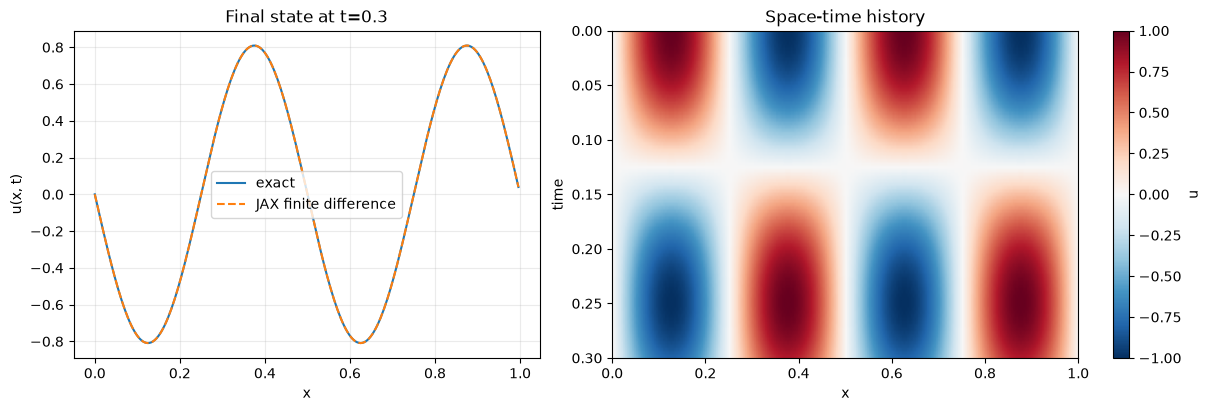

In [7]:
history = wave_history_jit(u0, v0, speed, dt, dx, n_steps)
history.block_until_ready()
times = np.arange(n_steps + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(np.asarray(x), np.asarray(u_exact), label="exact")
axes[0].plot(np.asarray(x), np.asarray(u_final), "--", label="JAX finite difference")
axes[0].set(xlabel="x", ylabel="u(x, t)", title=f"Final state at t={final_time}")
axes[0].legend()
axes[0].grid(alpha=0.25)

image = axes[1].imshow(
    np.asarray(history),
    extent=(0.0, length, final_time, 0.0),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1.0,
    vmax=1.0,
)
axes[1].set(xlabel="x", ylabel="time", title="Space-time history")
fig.colorbar(image, ax=axes[1], label="u")
plt.show()

The final curves should overlap closely. The space-time plot provides intuition, but neither plot establishes the method's order or conservation properties. Those require quantitative tests.

## 5. Check grid convergence

The centred spatial difference, leapfrog update, and Taylor start are all second order. With a fixed CFL number, $\Delta t$ is proportional to $\Delta x$, so we expect the total error to behave as $O(\Delta x^2)$.

In [8]:
def run_refinement(n, speed=1.0, final_time=0.3, length=1.0, mode=2):
    dx_n = length / n
    x_n = jnp.arange(n, dtype=jnp.float64) * dx_n
    target_dt_n = 0.8 * dx_n / speed
    steps_n = int(np.ceil(final_time / target_dt_n))
    dt_n = final_time / steps_n

    initial = standing_wave_exact(x_n, 0.0, speed, length, mode)
    velocity = jnp.zeros_like(initial)
    numerical = solve_wave_jit(
        initial, velocity, speed, dt_n, dx_n, steps_n
    )
    exact = standing_wave_exact(x_n, final_time, speed, length, mode)
    error = jnp.linalg.norm(numerical - exact) / jnp.linalg.norm(exact)
    return dx_n, float(error)


grid_sizes = np.array([32, 64, 128, 256])
refinement_results = [run_refinement(int(n)) for n in grid_sizes]
grid_spacings = np.array([item[0] for item in refinement_results])
errors = np.array([item[1] for item in refinement_results])
observed_order = np.polyfit(np.log(grid_spacings), np.log(errors), 1)[0]

for n, error in zip(grid_sizes, errors):
    print(f"N={n:4d}: relative L2 error = {error:.3e}")
print(f"observed convergence order: {observed_order:.2f}")

N=  32: relative L2 error = 6.356e-03
N=  64: relative L2 error = 1.585e-03
N= 128: relative L2 error = 3.961e-04
N= 256: relative L2 error = 9.900e-05
observed convergence order: 2.00


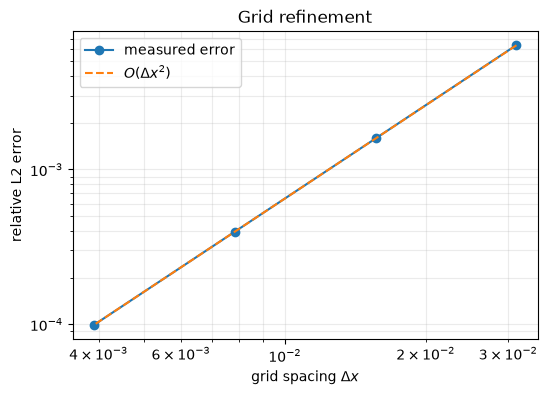

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(grid_spacings, errors, "o-", label="measured error")
reference = errors[-1] * (grid_spacings / grid_spacings[-1]) ** 2
ax.loglog(grid_spacings, reference, "--", label=r"$O(\Delta x^2)$")
ax.set(xlabel=r"grid spacing $\Delta x$", ylabel="relative L2 error", title="Grid refinement")
ax.legend()
ax.grid(which="both", alpha=0.25)
plt.show()

## 6. Check a discrete energy invariant

The continuous periodic wave equation conserves

$$E(t)=\tfrac{1}{2}\int_0^L\left[u_t^2+c^2u_x^2\right]\,dx.$$

The leapfrog scheme has a closely related invariant at half time steps:

$$
E^{n+1/2}=\frac{\Delta x}{2}\sum_i\left[
\left(\frac{u_i^{n+1}-u_i^n}{\Delta t}\right)^2
+c^2(D_+u_i^n)(D_+u_i^{n+1})\right].
$$

Checking the invariant is stronger than checking that the solution merely remains finite. It can expose indexing and update-order mistakes that preserve the general appearance of a wave.

The heat-equation example maps a function over one parameter array. Here `vmap` makes a small extension: `energy_for_pair` has two array arguments, and `in_axes=(0, 0)` maps over the leading axis of both. Consequently, row $n$ of `history[:-1]` is paired with row $n$ of `history[1:]`. This is an aligned, zip-like mapping that produces one energy per adjacent pair; it is not a Cartesian product of all time-level pairs.

maximum relative energy drift: 1.981e-15


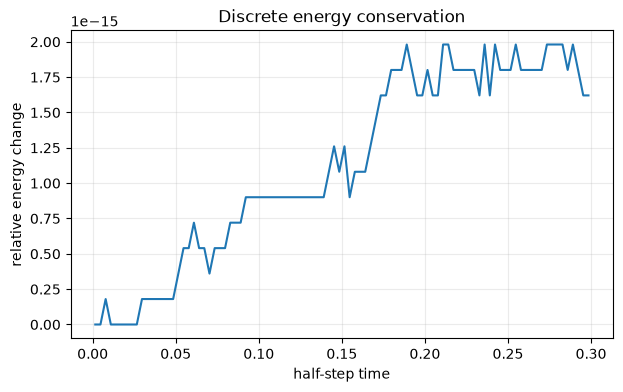

In [10]:
def discrete_energy(previous, current, speed, dt, dx):
    velocity = (current - previous) / dt
    gradient_previous = (jnp.roll(previous, -1) - previous) / dx
    gradient_current = (jnp.roll(current, -1) - current) / dx
    density = velocity**2 + speed**2 * gradient_previous * gradient_current
    return 0.5 * dx * jnp.sum(density)


def energy_for_pair(previous, current):
    return discrete_energy(previous, current, speed, dt, dx)


energy_over_pairs = jax.vmap(energy_for_pair, in_axes=(0, 0))
energies = energy_over_pairs(history[:-1], history[1:])
relative_energy_change = (energies - energies[0]) / energies[0]
maximum_energy_drift = float(jnp.max(jnp.abs(relative_energy_change)))

print(f"maximum relative energy drift: {maximum_energy_drift:.3e}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(times[1:] - 0.5 * dt, np.asarray(relative_energy_change))
ax.set(xlabel="half-step time", ylabel="relative energy change", title="Discrete energy conservation")
ax.grid(alpha=0.25)
plt.show()

Very small drift is expected in 64-bit arithmetic because this diagnostic matches the discrete scheme. A diagnostic based on the continuous energy with independently approximated derivatives would generally oscillate by the discretization error instead. Choosing the invariant that matches the method matters.

## 7. Stable does not mean non-dispersive

For a Fourier mode with wave number $k$, the leapfrog scheme obeys

$$
\sin\left(\frac{\omega_h\Delta t}{2}\right)
=\lambda\sin\left(\frac{k\Delta x}{2}\right).
$$

The numerical angular frequency $\omega_h$ is not exactly $ck$. Therefore different resolved wavelengths travel with different numerical phase speeds.

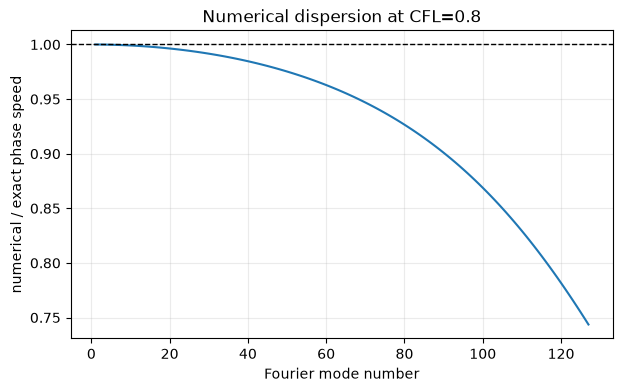

In [11]:
resolved_modes = np.arange(1, n_points // 2)
theta = 2.0 * np.pi * resolved_modes / n_points
numerical_omega = 2.0 / dt * np.arcsin(cfl * np.sin(theta / 2.0))
exact_omega = speed * theta / dx
phase_speed_ratio = numerical_omega / exact_omega

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(resolved_modes, phase_speed_ratio)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set(
    xlabel="Fourier mode number",
    ylabel="numerical / exact phase speed",
    title=f"Numerical dispersion at CFL={cfl:.1f}",
)
ax.grid(alpha=0.25)
plt.show()

Low modes, with many grid points per wavelength, propagate accurately. Modes near the grid scale can be badly delayed even though $\lambda<1$. Refinement is therefore needed for accuracy, not merely for stability.

## 8. Differentiate a physical diagnostic

For the standing wave, project the final state onto the initial sine mode. The exact modal amplitude is $A(c)=\cos(ckt)$, with derivative

$$\frac{dA}{dc}=-kt\sin(ckt).$$

We differentiate the numerical amplitude and compare it with this analytical sensitivity. The time step and number of steps remain fixed while $c$ changes. Differentiating through an integer step-selection rule would not give a useful smooth derivative. The CFL condition must remain valid in the neighbourhood being studied.

In [12]:
def numerical_modal_amplitude(candidate_speed):
    final = solve_wave(u0, v0, candidate_speed, dt, dx, n_steps)
    return 2.0 * jnp.mean(final * u0)


amplitude_and_gradient = jax.jit(
    jax.value_and_grad(numerical_modal_amplitude)
)
numerical_amplitude, numerical_gradient = amplitude_and_gradient(speed)

wave_number = 2.0 * np.pi * mode / length
exact_amplitude = np.cos(speed * wave_number * final_time)
exact_gradient = -wave_number * final_time * np.sin(
    speed * wave_number * final_time
)
gradient_error = abs(float(numerical_gradient) - exact_gradient)

print(f"numerical amplitude: {float(numerical_amplitude): .6f}")
print(f"exact amplitude:     {exact_amplitude: .6f}")
print(f"numerical dA/dc:    {float(numerical_gradient): .6f}")
print(f"exact dA/dc:        {exact_gradient: .6f}")
print(f"absolute gradient error: {gradient_error:.3e}")

numerical amplitude: -0.809097
exact amplitude:     -0.809017
numerical dA/dc:     2.215687
exact dA/dc:         2.215898
absolute gradient error: 2.110e-04


The numerical gradient is a derivative of the discretized solver. Agreement with the continuum derivative is another convergence question; automatic differentiation guarantees neither physical relevance nor discretization accuracy.

## 9. Exercises

The core tutorial ends here. The following exercises require prediction and interpretation rather than transcription.

### Exercise 1 — diagnose a CFL violation (10 minutes)

Use the alternating grid mode $[1,-1,1,-1,\ldots]$, which is the highest spatial frequency representable on an even grid.

1. Predict the qualitative difference between $\lambda=0.95$ and $\lambda=1.05$.
2. Explain why a smooth low-frequency initial condition might hide the problem for a while.
3. Run the solution cell and identify whether the failure is caused by JAX, roundoff, or the numerical method.

**Success criterion:** connect the observed growth to the worst-case Fourier mode and the CFL limit.

<details>
<summary><strong>Reasoning</strong></summary>

The alternating mode maximizes the magnitude of the discrete Laplacian. At $\lambda\le1$, the leapfrog amplification factors remain on the unit circle; beyond one, a real amplification factor has magnitude greater than one. A smooth state initially contains little energy in this mode, but perturbations and roundoff can eventually excite it. The instability belongs to the finite-difference method.
</details>

In [13]:
alternating_mode = jnp.where(jnp.arange(n_points) % 2 == 0, 1.0, -1.0)
zero_velocity = jnp.zeros_like(alternating_mode)
exercise_steps = 30

def maximum_amplitude_after(cfl_number):
    exercise_dt = cfl_number * dx / speed
    result = solve_wave_jit(
        alternating_mode, zero_velocity, speed, exercise_dt, dx, exercise_steps
    )
    return float(jnp.max(jnp.abs(result)))


stable_amplitude = maximum_amplitude_after(0.95)
unstable_amplitude = maximum_amplitude_after(1.05)
print(f"maximum amplitude at CFL=0.95: {stable_amplitude:.3e}")
print(f"maximum amplitude at CFL=1.05: {unstable_amplitude:.3e}")

maximum amplitude at CFL=0.95: 9.792e-01
maximum amplitude at CFL=1.05: 8.039e+07


### Exercise 2 — launch a one-way travelling wave (15–20 minutes)

A sine displacement with zero initial velocity splits into equal left- and right-moving waves. For

$$u(x,t)=\sin[k(x-ct)],$$

derive $v_0(x)=u_t(x,0)$, including its sign. Then reuse the solver and compare with the exact travelling wave.

**Hint.** Differentiate the complete phase $k(x-ct)$ with respect to time.

**Success criterion:** choose the velocity sign from the desired direction of travel and obtain a small relative error without modifying the step function.

<details>
<summary><strong>Reasoning</strong></summary>

Differentiating gives $u_t=-ck\cos[k(x-ct)]$, so $v_0(x)=-ck\cos(kx)$. Reversing the sign launches the wave in the opposite direction. The solver needs no change because displacement and velocity are explicit inputs.
</details>

travelling-wave relative L2 error: 1.013e-04


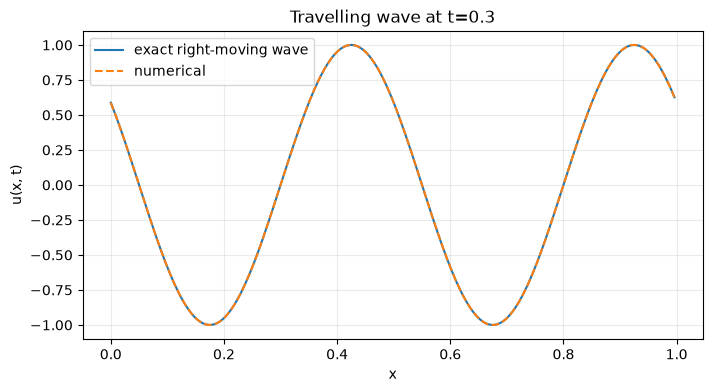

In [14]:
travelling_u0 = jnp.sin(wave_number * x)
travelling_v0 = -speed * wave_number * jnp.cos(wave_number * x)
travelling_numerical = solve_wave_jit(
    travelling_u0, travelling_v0, speed, dt, dx, n_steps
)
travelling_exact = jnp.sin(wave_number * (x - speed * final_time))
travelling_error = float(
    jnp.linalg.norm(travelling_numerical - travelling_exact)
    / jnp.linalg.norm(travelling_exact)
)
print(f"travelling-wave relative L2 error: {travelling_error:.3e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.asarray(x), np.asarray(travelling_exact), label="exact right-moving wave")
ax.plot(np.asarray(x), np.asarray(travelling_numerical), "--", label="numerical")
ax.set(xlabel="x", ylabel="u(x, t)", title=f"Travelling wave at t={final_time}")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 10. Limits and next steps

### What JAX contributes

- compilation of the complete time loop for CPU or accelerator backends;
- tuple PyTrees as explicit multi-array loop state;
- `scan` for compiled recurrence plus selected history;
- `vmap` over aligned axes of multiple arguments;
- composable vectorization and automatic differentiation.

### What remains a numerical-science responsibility

- consistent initialization and boundary conditions;
- CFL stability, resolution, convergence, and invariant checks;
- deciding whether the memory cost of stored history is acceptable;
- recognizing that explicit time stepping becomes expensive on fine grids;
- validating discrete sensitivities against the continuum question of interest.

Natural extensions include absorbing or reflecting boundaries, spatially varying wave speed, two-dimensional propagation, forcing, damping, batched sources with `vmap`, checkpointed gradients, and multi-device domain decomposition. Each adds a scientific complication; none is solved merely by adding `jit`.

## 11. Reproducibility checks

These smoke checks cover the notebook's main claims. They are useful regression tests, not a proof that the method is suitable for a new PDE or boundary condition.

In [15]:
assert cfl <= 1.0
assert relative_l2_error < 1.0e-3
assert 1.8 < observed_order < 2.2
assert maximum_energy_drift < 1.0e-10
assert gradient_error < 1.0e-2
assert unstable_amplitude > 100.0 * stable_amplitude
assert travelling_error < 1.0e-3
print("All wave-equation tutorial checks passed.")

All wave-equation tutorial checks passed.


## References

- [JAX: Just-in-time compilation](https://docs.jax.dev/en/latest/jit-compilation.html)
- [JAX: Control-flow operators](https://docs.jax.dev/en/latest/control-flow.html)
- [JAX: `lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [JAX: PyTrees](https://docs.jax.dev/en/latest/pytrees.html)
- [JAX: Automatic vectorization](https://docs.jax.dev/en/latest/jax-101/03-vectorization.html)
- [JAX: The Autodiff Cookbook](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)